# Homework Description
- English to Chinese (Traditional) Translation
  - Input: an English sentence         (e.g.		tom is a student .)
  - Output: the Chinese translation  (e.g. 		湯姆 是 個 學生 。)

- TODO
    - Train a simple RNN seq2seq to acheive translation
    - Switch to transformer model to boost performance
    - Apply Back-translation to furthur boost performance

In [1]:
# !nvidia-smi

# Download and import required packages

In [2]:
# !pip install  editdistance matplotlib sacrebleu sacremoses sentencepiece tqdm wandb
# !pip install --upgrade jupyter ipywidgets

In [3]:
# !git clone https://github.com/pytorch/fairseq.git
# !cd fairseq && git checkout 9a1c497
# # !pip install --upgrade ./fairseq/

In [4]:
import sys
import pdb
import pprint
import logging
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
import numpy as np
import tqdm.auto as tqdm
from pathlib import Path
from argparse import Namespace
from fairseq import utils

import matplotlib.pyplot as plt

c:\Users\admin\.conda\envs\AI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-10-21 08:48:48 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


# Fix random seed

In [5]:
seed = 73
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
np.random.seed(seed)  
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Dataset

## En-Zh Bilingual Parallel Corpus
* [TED2020](#reimers-2020-multilingual-sentence-bert)
    - Raw: 398,066 (sentences)   
    - Processed: 393,980 (sentences)
    

## Testdata
- Size: 4,000 (sentences)
- **Chinese translation is undisclosed. The provided (.zh) file is psuedo translation, each line is a '。'**

## Dataset Download

In [6]:
import os
import requests
from pathlib import Path
import tarfile
import shutil

data_dir = './DATA/rawdata'
dataset_name = 'ted2020'

urls = (
    "https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ml2023.hw5.data.tgz",
    "https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ml2023.hw5.test.tgz"
)

file_names = (
    'ted2020.tgz', # train & dev
    'test.tgz', # test
)

prefix = Path(data_dir).absolute() / dataset_name

prefix.mkdir(parents=True, exist_ok=True)

for u, f in zip(urls, file_names):
    path = prefix/f
    if not path.exists():
        !curl -o {path} {u}
    if path.suffix == ".tgz":
        !tar -xvf {path} -C {prefix}
    elif path.suffix == ".zip":
        !tar -xf {path} -C {prefix}



# 移动和重命名文件
shutil.move(str(prefix / 'raw.en'), str(prefix / 'train_dev.raw.en'))
shutil.move(str(prefix / 'raw.zh'), str(prefix / 'train_dev.raw.zh'))
shutil.move(str(prefix / 'test.en'), str(prefix / 'test.raw.en'))
shutil.move(str(prefix / 'test.zh'), str(prefix / 'test.raw.zh'))


x raw.en
x raw.zh
x test.en
x test.zh


'e:\\Learn\\Lhy_Machine_Learning-main\\2022-ML\\05-Sequence_to_sequence\\DATA\\rawdata\\ted2020\\test.raw.zh'

## Language

In [7]:
src_lang = 'en'
tgt_lang = 'zh'

data_prefix = f'{prefix}/train_dev.raw'
test_prefix = f'{prefix}/test.raw'


In [8]:
# !head {data_prefix+'.'+src_lang} -n 5
# !head {data_prefix+'.'+tgt_lang} -n 5

# !powershell -Command "Get-Content -Path {data_prefix+'.'+src_lang} -TotalCount 5"
# !powershell -Command "Get-Content -Path {data_prefix+'.'+tgt_lang} -TotalCount 5"

!powershell -Command "Get-Content -Path {data_prefix+'.'+src_lang} -TotalCount 5 | Out-File -FilePath temp_src.txt -Encoding utf8; Get-Content temp_src.txt"
!powershell -Command "Get-Content -Path {data_prefix+'.'+tgt_lang} -TotalCount 5 | Out-File -FilePath temp_tgt.txt -Encoding utf8; Get-Content temp_tgt.txt"

Thank you so much, Chris.
And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful.
I have been blown away by this conference, and I want to thank all of you for the many nice comments about what I had to say the other night.
And I say that sincerely, partly because I need that.
Put yourselves in my position.
非常謝謝你，克里斯。能有這個機會第二度踏上這個演講台
真是一大榮幸。我非常感激�?這個研討會給我留下了極為深刻的印象，我想感謝大�?對我之前演講的好評�?我是由衷的想這麼說，有部份原因是因為 —�?我真的有需�?
請你們設身處地為我想一想！
我曾搭乘副總統專機八年�?現在我卻必須脫了鞋子才能上飛�?
讓我跟你們說一個很短的故事，你們就會明白我的日子是怎麼過的�?這是一個真實的故事 �?徹頭徹尾都是真實的�?在我跟我夫人蒂佩爾離�?—�?白宮 —�?�?我們從那什維爾的家開車�?東邊 50 英哩外的一個我們擁有的小農�?�?自己開車去�?我知道這對你們來說是一件小事，但是 —�?當我看了後照鏡後，才突然驚覺�?車後並沒有車隊跟隨�?我想大家都聽過「鬼腳痛」吧�?那是一部租來的福特金牛座汽車。正值晚餐時刻，


## Preprocess files

In [9]:
# 对标点符号进行处理
import re

def strQ2B(ustring):
    """Full width -> half width"""
    # reference:https://ithelp.ithome.com.tw/articles/10233122
    ss = []
    for s in ustring:
        rstring = ""
        for uchar in s:
            inside_code = ord(uchar)
            if inside_code == 12288:  # Full width space: direct conversion
                inside_code = 32
            elif (inside_code >= 65281 and inside_code <= 65374):  # Full width chars (except space) conversion
                inside_code -= 65248
            rstring += chr(inside_code)
        ss.append(rstring)
    return ''.join(ss)
                
def clean_s(s, lang):
    if lang == 'en':
        s = re.sub(r"\([^()]*\)", "", s) # remove ([text])
        s = s.replace('-', '') # remove '-'
        s = re.sub('([.,;!?()\"])', r' \1 ', s) # keep punctuation
    elif lang == 'zh':
        s = strQ2B(s) # Q2B
        s = re.sub(r"\([^()]*\)", "", s) # remove ([text])
        s = s.replace(' ', '')
        s = s.replace('—', '')
        s = s.replace('“', '"')
        s = s.replace('”', '"')
        s = s.replace('_', '')
        s = re.sub('([。,;!?()\"~「」])', r' \1 ', s) # keep punctuation
    s = ' '.join(s.strip().split())
    return s

def len_s(s, lang):
    if lang == 'zh':
        return len(s)
    return len(s.split())

def clean_corpus(prefix, l1, l2, ratio=9, max_len=1000, min_len=1):
    if Path(f'{prefix}.clean.{l1}').exists() and Path(f'{prefix}.clean.{l2}').exists():
        print(f'{prefix}.clean.{l1} & {l2} exists. skipping clean.')
        return
    with open(f'{prefix}.{l1}', 'r') as l1_in_f:
        with open(f'{prefix}.{l2}', 'r') as l2_in_f:
            with open(f'{prefix}.clean.{l1}', 'w') as l1_out_f:
                with open(f'{prefix}.clean.{l2}', 'w') as l2_out_f:
                    for s1 in l1_in_f:
                        s1 = s1.strip()
                        s2 = l2_in_f.readline().strip()
                        s1 = clean_s(s1, l1)
                        s2 = clean_s(s2, l2)
                        s1_len = len_s(s1, l1)
                        s2_len = len_s(s2, l2)
                        if min_len > 0: # remove short sentence
                            if s1_len < min_len or s2_len < min_len:
                                continue
                        if max_len > 0: # remove long sentence
                            if s1_len > max_len or s2_len > max_len:
                                continue
                        if ratio > 0: # remove by ratio of length
                            if s1_len/s2_len > ratio or s2_len/s1_len > ratio:
                                continue
                        print(s1, file=l1_out_f)
                        print(s2, file=l2_out_f)

In [10]:
clean_corpus(data_prefix, src_lang, tgt_lang)
clean_corpus(test_prefix, src_lang, tgt_lang, ratio=-1, min_len=-1, max_len=-1)

e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020/train_dev.raw.clean.en & zh exists. skipping clean.
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020/test.raw.clean.en & zh exists. skipping clean.


In [11]:
# !head {data_prefix+'.clean.'+src_lang} -n 5
# !head {data_prefix+'.clean.'+tgt_lang} -n 5

# 看下处理的效果


# with ... as ...: 
# 调用上下文管理器对象的 __enter__ 方法，并将返回值赋给 as 后面的变量。
# 执行 with 代码块中的代码。
# 无论代码块是否正常结束，都会调用上下文管理器对象的 __exit__ 方法，以确保资源被正确释放。

# 读取并显示文件的前 5 行
def display_file_head(file_path, num_lines=5):
    with open(file_path, 'r', encoding='utf-8') as file:
        for _ in range(num_lines):
            print(file.readline().strip())

# 显示源语言和目标语言文件的前 5 行
display_file_head(f"{data_prefix}.clean.{src_lang}")
display_file_head(f"{data_prefix}.clean.{tgt_lang}")

Thank you so much , Chris .
And it's truly a great honor to have the opportunity to come to this stage twice ; I'm extremely grateful .
I have been blown away by this conference , and I want to thank all of you for the many nice comments about what I had to say the other night .
And I say that sincerely , partly because I need that .
Put yourselves in my position .
非常謝謝你 , 克里斯 。 能有這個機會第二度踏上這個演講台
真是一大榮幸 。 我非常感激 。
這個研討會給我留下了極為深刻的印象 , 我想感謝大家對我之前演講的好評 。
我是由衷的想這麼說 , 有部份原因是因為我真的有需要 !
請你們設身處地為我想一想 !


## Split into train/valid

In [12]:
valid_ratio = 0.01 # 3000~4000 would suffice
train_ratio = 1 - valid_ratio

In [13]:
# 划分测试集和训练集

if (prefix/f'train.clean.{src_lang}').exists() \
and (prefix/f'train.clean.{tgt_lang}').exists() \
and (prefix/f'valid.clean.{src_lang}').exists() \
and (prefix/f'valid.clean.{tgt_lang}').exists():\
    print(f'train/valid splits exists. skipping split.')
else:
    line_num = sum(1 for line in open(f'{data_prefix}.clean.{src_lang}')) ## 文件行数

    labels = list(range(line_num))
    random.shuffle(labels) ## 打乱顺序

    for lang in [src_lang, tgt_lang]:
        train_f = open(os.path.join(data_dir, dataset_name, f'train.clean.{lang}'), 'w')
        valid_f = open(os.path.join(data_dir, dataset_name, f'valid.clean.{lang}'), 'w')
        count = 0
        for line in open(f'{data_prefix}.clean.{lang}', 'r'):
            if labels[count]/line_num < train_ratio:
                train_f.write(line)
            else:
                valid_f.write(line)
            count += 1
        train_f.close()
        valid_f.close()

train/valid splits exists. skipping split.


## Subword Units 
Out of vocabulary (OOV) has been a major problem in machine translation. This can be alleviated by using subword units.
- We will use the [sentencepiece](#kudo-richardson-2018-sentencepiece) package
- select 'unigram' or 'byte-pair encoding (BPE)' algorithm

In [14]:
# OOV：Out Of Vocabulary，指的是在训练集中没有出现过但在测试集中出现了的的词汇
# 使用拆分的方法将单词拆成一个或者多个token，可以在一定程度上缓解OOV问题

# 使用 SentencePiece 对数据进行分词
import sentencepiece as spm
vocab_size = 8000
if (prefix/f'spm{vocab_size}.model').exists():
    print(f'{prefix}/spm{vocab_size}.model exists. skipping spm_train.')
else:
    spm.SentencePieceTrainer.train(
        input=','.join([f'{prefix}/train.clean.{src_lang}',
                        f'{prefix}/valid.clean.{src_lang}',
                        f'{prefix}/train.clean.{tgt_lang}',
                        f'{prefix}/valid.clean.{tgt_lang}']),
        model_prefix=prefix/f'spm{vocab_size}',
        vocab_size=vocab_size,
        character_coverage=1,
        model_type='unigram', # 'bpe' works as well
        input_sentence_size=1e6,
        shuffle_input_sentence=True,
        normalization_rule_name='nmt_nfkc_cf',
    )

e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020/spm8000.model exists. skipping spm_train.


In [15]:
# 生成由 unigram 模型处理过后的文件

spm_model = spm.SentencePieceProcessor(model_file=str(prefix/f'spm{vocab_size}.model'))
in_tag = {
    'train': 'train.clean',
    'valid': 'valid.clean',
    'test': 'test.raw.clean',
}
for split in ['train', 'valid', 'test']:
    for lang in [src_lang, tgt_lang]:
        out_path = prefix/f'{split}.{lang}'
        if out_path.exists():
            print(f"{out_path} exists. skipping spm_encode.")
        else:
            with open(prefix/f'{split}.{lang}', 'w') as out_f:
                with open(prefix/f'{in_tag[split]}.{lang}', 'r') as in_f:
                    for line in in_f:
                        line = line.strip()
                        tok = spm_model.encode(line, out_type=str)
                        print(' '.join(tok), file=out_f)

e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020\train.en exists. skipping spm_encode.
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020\train.zh exists. skipping spm_encode.
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020\valid.en exists. skipping spm_encode.
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\ted2020\valid.zh exists. skipping spm_encode.


In [16]:
# !head {data_dir+'/'+dataset_name+'/train.'+src_lang} -n 5
# !head {data_dir+'/'+dataset_name+'/train.'+tgt_lang} -n 5

# 读取并显示文件的前 5 行
def display_file_head(file_path, num_lines=5):
    with open(file_path, 'r', encoding='utf-8') as file:
        for _ in range(num_lines):
            print(file.readline().strip())

# 显示源语言和目标语言文件的前 5 行
display_file_head(f"{data_dir}/{dataset_name}/train.{src_lang}")
display_file_head(f"{data_dir}/{dataset_name}/train.{tgt_lang}")

▁thank ▁you ▁so ▁much ▁, ▁chris ▁.
▁and ▁it ' s ▁ t ru ly ▁a ▁great ▁ho n or ▁to ▁have ▁the ▁opportunity ▁to ▁come ▁to ▁this ▁stage ▁ t wi ce ▁; ▁i ' m ▁extreme ly ▁gr ate ful ▁.
▁i ▁have ▁been ▁ bl ow n ▁away ▁by ▁this ▁con f er ence ▁, ▁and ▁i ▁want ▁to ▁thank ▁all ▁of ▁you ▁for ▁the ▁many ▁ ni ce ▁ com ment s ▁about ▁what ▁i ▁had ▁to ▁say ▁the ▁other ▁night ▁.
▁and ▁i ▁say ▁that ▁since re ly ▁, ▁part ly ▁because ▁i ▁need ▁that ▁.
▁put ▁your s el ve s ▁in ▁my ▁po s ition ▁.
▁ 非常 謝 謝 你 ▁, ▁ 克 里 斯 ▁。 ▁ 能 有 這個 機會 第二 度 踏 上 這個 演講 台
▁ 真 是 一 大 榮 幸 ▁。 ▁我 非常 感 激 ▁。
▁這個 研 討 會 給我 留 下 了 極 為 深 刻 的 印 象 ▁, ▁我想 感 謝 大家 對 我 之前 演講 的 好 評 ▁。
▁我 是由 衷 的 想 這麼 說 ▁, ▁有 部份 原因 是因為 我 真的 有 需要 ▁!
▁ 請 你們 設 身 處 地 為 我想 一 想 ▁!


## Binarize the data with fairseq

In [17]:
# 将文本转换成张量，以便数据可以喂给模型

binpath = Path('./DATA/data-bin', dataset_name)
if binpath.exists():
    print(binpath, "exists, will not overwrite!")
else:
    !python -m fairseq_cli.preprocess \
        --source-lang {src_lang}\
        --target-lang {tgt_lang}\
        --trainpref {prefix/'train'}\
        --validpref {prefix/'valid'}\
        --testpref {prefix/'test'}\
        --destdir {binpath}\
        --joined-dictionary\
        --workers 2

DATA\data-bin\ted2020 exists, will not overwrite!


# Configuration for experiments

In [18]:
config = Namespace(
    datadir = "./DATA/data-bin/ted2020_with_mono",
    savedir = "./checkpoints/transformer-ted2020_with_mono",
    
    source_lang = "en",
    target_lang = "zh",
    
    # cpu threads when fetching & processing data.
    num_workers=2,  

    # batch size in terms of tokens. gradient accumulation increases the effective batchsize.
    max_tokens=8192,
    accum_steps=2,

    
    # the lr s calculated from Noam lr scheduler. you can tune the maximum lr by this factor.
    lr_factor=2.,
    lr_warmup=4000,
    
    # clipping gradient norm helps alleviate gradient exploding
    clip_norm=1.0,
    
    # maximum epochs for training
    max_epoch=30,
    start_epoch=1,
    
    # beam size for beam search
    beam=5, 
    # generate sequences of maximum length ax + b, where x is the source length
    max_len_a=1.2, 
    max_len_b=10, 

    # when decoding, post process sentence by removing sentencepiece symbols and jieba tokenization.
    post_process = "sentencepiece",
    
    # checkpoints
    keep_last_epochs=5,
    resume=None, # if resume from checkpoint name (under config.savedir)
    
    # logging
    use_wandb=False,
)

# Logging
- logging package logs ordinary messages
- wandb logs the loss, bleu, etc. in the training process

In [19]:
logging.basicConfig(
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    level="INFO", # "DEBUG" "WARNING" "ERROR"
    stream=sys.stdout,
)

proj = "hw5.seq2seq"
logger = logging.getLogger(proj)

if config.use_wandb:
    import wandb
    wandb.init(project=proj, name=Path(config.savedir).stem, config=config)

# CUDA Environments

In [20]:
cuda_env = utils.CudaEnvironment()
utils.CudaEnvironment.pretty_print_cuda_env_list([cuda_env])
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

2024-10-21 08:48:51 | INFO | fairseq.utils | ***********************CUDA enviroments for all 1 workers***********************
2024-10-21 08:48:51 | INFO | fairseq.utils | rank   0: capabilities =  8.9  ; total memory = 7.996 GB ; name = NVIDIA GeForce RTX 4060 Ti              
2024-10-21 08:48:51 | INFO | fairseq.utils | ***********************CUDA enviroments for all 1 workers***********************


# Dataloading

## We borrow the TranslationTask from fairseq
* used to load the binarized data created above
* well-implemented data iterator (dataloader)
* built-in task.source_dictionary and task.target_dictionary are also handy
* well-implemented beach search decoder

In [21]:
from fairseq.tasks.translation import TranslationConfig, TranslationTask

## setup task
## 把张量翻译回文本

task_cfg = TranslationConfig(
    data=config.datadir,
    source_lang=config.source_lang,
    target_lang=config.target_lang,
    train_subset="train",
    required_seq_len_multiple=8,
    dataset_impl="mmap",
    upsample_primary=1,
)

task = TranslationTask.setup_task(task_cfg)

2024-10-21 08:48:51 | INFO | fairseq.tasks.translation | [en] dictionary: 7984 types
2024-10-21 08:48:51 | INFO | fairseq.tasks.translation | [zh] dictionary: 7984 types


In [22]:
logger.info("loading data for epoch 1")
task.load_dataset(split="train", epoch=1, combine=True) # combine if you have back-translation data.
task.load_dataset(split="valid", epoch=1)

2024-10-21 08:48:51 | INFO | hw5.seq2seq | loading data for epoch 1
2024-10-21 08:48:51 | INFO | fairseq.data.data_utils | loaded 390,112 examples from: ./DATA/data-bin/ted2020_with_mono\train.en-zh.en
2024-10-21 08:48:51 | INFO | fairseq.data.data_utils | loaded 390,112 examples from: ./DATA/data-bin/ted2020_with_mono\train.en-zh.zh
2024-10-21 08:48:51 | INFO | fairseq.tasks.translation | ./DATA/data-bin/ted2020_with_mono train en-zh 390112 examples
2024-10-21 08:48:52 | INFO | fairseq.data.data_utils | loaded 781,713 examples from: ./DATA/data-bin/ted2020_with_mono\train1.en-zh.en
2024-10-21 08:48:52 | INFO | fairseq.data.data_utils | loaded 781,713 examples from: ./DATA/data-bin/ted2020_with_mono\train1.en-zh.zh
2024-10-21 08:48:52 | INFO | fairseq.tasks.translation | ./DATA/data-bin/ted2020_with_mono train1 en-zh 781713 examples
2024-10-21 08:48:52 | INFO | fairseq.data.data_utils | loaded 3,940 examples from: ./DATA/data-bin/ted2020_with_mono\valid.en-zh.en
2024-10-21 08:48:52 | I

In [23]:
sample = task.dataset("valid")[0]

pprint.pprint(sample)

pprint.pprint(
    "Source: " + \
    task.source_dictionary.string(
        sample['source'],
        config.post_process,
    )
)

pprint.pprint(
    "Target: " + \
    task.target_dictionary.string(
        sample['target'],
        config.post_process,
    )
)


{'id': 0,
 'source': tensor([  19,  284,   12,  646,   63,   13, 2236,   16,   19,   15,   33,  198,
          12,  544,  212,  291, 1621,    6,    4,   11,   19,   15,   33,  198,
          12,    5,   24,  770, 1386,   14,  228,  151,  130, 1145,   98, 1362,
           7,    2]),
 'target': tensor([ 948,  303,  518,  226,  405, 1180,  539, 1233,    4,   39,   62, 4097,
        1713,  938,  735,  298,  759,  924,   10,    2])}
("Source: i want to start with a couple of i'm going to show some new images , "
 "and i'm going to recapitulate just four or five .")
'Target: 我想給你們看一些新的圖象 , 我會概述其中四或五張 。'


# Dataset iterator

* Controls every batch to contain no more than N tokens, which optimizes GPU memory efficiency
* Shuffles the training set for every epoch
* Ignore sentences exceeding maximum length
* Pad all sentences in a batch to the same length, which enables parallel computing by GPU
* Add eos and shift one token
    - teacher forcing: to train the model to predict the next token based on prefix, we feed the right shifted target sequence as the decoder input.
    - generally, prepending bos to the target would do the job (as shown below)
![seq2seq](https://i.imgur.com/0zeDyuI.png)
    - in fairseq however, this is done by moving the eos token to the begining. Empirically, this has the same effect. For instance:
    ```
    # output target (target) and Decoder input (prev_output_tokens): 
                   eos = 2
                target = 419,  711,  238,  888,  792,   60,  968,    8,    2
    prev_output_tokens = 2,  419,  711,  238,  888,  792,   60,  968,    8
    ```



In [24]:
def load_data_iterator(task, split, epoch=1, max_tokens=4000, num_workers = 0, cached=True):
    batch_iterator = task.get_batch_iterator(
        dataset=task.dataset(split),
        max_tokens=max_tokens,
        max_sentences=None,
        max_positions=utils.resolve_max_positions(
            task.max_positions(),
            max_tokens,
        ),
        ignore_invalid_inputs=True,
        seed=seed,
        num_workers=num_workers,
        epoch=epoch,
        disable_iterator_cache=not cached,
        # Set this to False to speed up. However, if set to False, changing max_tokens beyond 
        # first call of this method has no effect. 
    )
    return batch_iterator

demo_epoch_obj = load_data_iterator(task, "valid", epoch=1, max_tokens=20, num_workers = 0, cached=False)
demo_iter = demo_epoch_obj.next_epoch_itr(shuffle=True)

sample = next(demo_iter)
sample

2024-10-21 08:48:52 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = False
2024-10-21 08:48:52 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-10-21 08:48:52 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-10-21 08:48:52 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1
2024-10-21 08:48:52 | WARNING | fairseq.tasks.fairseq_task | 2,580 samples have invalid sizes and will be skipped, max_positions=(20, 20), first few sample ids=[1225, 839, 1298, 626, 2375, 1102, 1196, 3466, 3513, 3493]


{'id': tensor([2755]),
 'nsentences': 1,
 'ntokens': 14,
 'net_input': {'src_tokens': tensor([[  1, 462,  45,  25, 188, 555,  21,  89, 101,  13, 187,  52, 998, 142,
             7,   2]]),
  'src_lengths': tensor([15]),
  'prev_output_tokens': tensor([[   2,    5,  528,   45,   87,  492,   41,   90,  184,   55,  778, 5517,
            394,   10,    1,    1]])},
 'target': tensor([[   5,  528,   45,   87,  492,   41,   90,  184,   55,  778, 5517,  394,
            10,    2,    1,    1]])}

* each batch is a python dict, with string key and Tensor value. Contents are described below:
```python
batch = {
    "id": id, # id for each example 
    "nsentences": len(samples), # batch size (sentences)
    "ntokens": ntokens, # batch size (tokens)
    "net_input": {
        "src_tokens": src_tokens, # sequence in source language
        "src_lengths": src_lengths, # sequence length of each example before padding
        "prev_output_tokens": prev_output_tokens, # right shifted target, as mentioned above.
    },
    "target": target, # target sequence
}
```

# Model Architecture
* We again inherit fairseq's encoder, decoder and model, so that in the testing phase we can directly leverage fairseq's beam search decoder.

In [25]:
from fairseq.models import (
    FairseqEncoder, 
    FairseqIncrementalDecoder,
    FairseqEncoderDecoderModel
)

# Encoder

- The Encoder is a RNN or Transformer Encoder. The following description is for RNN. For every input token, Encoder will generate a output vector and a hidden states vector, and the hidden states vector is passed on to the next step. In other words, the Encoder sequentially reads in the input sequence, and outputs a single vector at each timestep, then finally outputs the final hidden states, or content vector, at the last timestep.
- Parameters:
  - *args*
      - encoder_embed_dim: the dimension of embeddings, this compresses the one-hot vector into fixed dimensions, which achieves dimension reduction
      - encoder_ffn_embed_dim is the dimension of hidden states and output vectors
      - encoder_layers is the number of layers for Encoder RNN
      - dropout determines the probability of a neuron's activation being set to 0, in order to prevent overfitting. Generally this is applied in training, and removed in testing.
  - *dictionary*: the dictionary provided by fairseq. it's used to obtain the padding index, and in turn the encoder padding mask. 
  - *embed_tokens*: an instance of token embeddings (nn.Embedding)

- Inputs: 
    - *src_tokens*: integer sequence representing english e.g. 1, 28, 29, 205, 2 
- Outputs: 
    - *outputs*: the output of RNN at each timestep, can be furthur processed by Attention
    - *final_hiddens*: the hidden states of each timestep, will be passed to decoder for decoding
    - *encoder_padding_mask*: this tells the decoder which position to ignore


In [26]:
class RNNEncoder(FairseqEncoder):

    def __init__(self, args, dictionary, embed_tokens):
        super().__init__(dictionary)

        self.embed_tokens = embed_tokens
        
        self.embed_dim = args.encoder_embed_dim
        self.hidden_dim = args.encoder_ffn_embed_dim
        self.num_layers = args.encoder_layers
        
        self.dropout_in_module = nn.Dropout(args.dropout)

        self.rnn = nn.GRU(
            self.embed_dim, 
            self.hidden_dim, 
            self.num_layers, 
            dropout=args.dropout, 
            batch_first=False, 
            bidirectional=True
        )
        self.dropout_out_module = nn.Dropout(args.dropout)
        
        self.padding_idx = dictionary.pad()

    # -1 代表根据其他维度的值来推断这个维度的值
    def combine_bidir(self, outs, bsz: int):
        out = outs.view(self.num_layers, bsz, 2, -1).contiguous()
        return out.view(self.num_layers, bsz, -1)

    def forward(self, src_tokens, **unused):

        bsz, seqlen = src_tokens.size()
        
        # get embeddings
        x = self.embed_tokens(src_tokens)
        x = self.dropout_in_module(x)

        # B x T x C -> T x B x C
        x = x.transpose(0, 1)
        
        # pass thru bidirectional RNN
        # 生成全0的张量作为初始隐藏状态
        h0 = x.new_zeros(2 * self.num_layers, bsz, self.hidden_dim)

        x, final_hiddens = self.rnn(x, h0)
        outputs = self.dropout_out_module(x)
        # directions = 2
        # outputs = [sequence len, batch size, hid dim * directions]
        # hidden =  [num_layers * directions, batch size  , hid dim]
        
        # Since Encoder is bidirectional, we need to concatenate the hidden states of two directions
        final_hiddens = self.combine_bidir(final_hiddens, bsz)
        # hidden =  [num_layers x batch x num_directions*hidden]
        
        # 掩码
        encoder_padding_mask = src_tokens.eq(self.padding_idx).t()

        return tuple(
            (
                outputs,  # seq_len x batch x num_directions*hidden
                final_hiddens,  # num_layers x batch x num_directions*hidden
                encoder_padding_mask,  # seq_len x batch
            )
        )
    
    def reorder_encoder_out(self, encoder_out, new_order):
        # This is used by fairseq's beam search. How and why is not particularly important here.
        return tuple(
            (
                encoder_out[0].index_select(1, new_order),
                encoder_out[1].index_select(1, new_order),
                encoder_out[2].index_select(1, new_order),
            )
        )

## Attention

- When the input sequence is long, "content vector" alone cannot accurately represent the whole sequence, attention mechanism can provide the Decoder more information.
- According to the **Decoder embeddings** of the current timestep, match the **Encoder outputs** with decoder embeddings to determine correlation, and then sum the Encoder outputs weighted by the correlation as the input to **Decoder** RNN.
- Common attention implementations use neural network / dot product as the correlation between **query** (decoder embeddings) and **key** (Encoder outputs), followed by **softmax**  to obtain a distribution, and finally **values** (Encoder outputs) is **weighted sum**-ed by said distribution.

- Parameters:
  - *input_embed_dim*: dimensionality of key, should be that of the vector in decoder to attend others
  - *source_embed_dim*: dimensionality of query, should be that of the vector to be attended to (encoder outputs)
  - *output_embed_dim*: dimensionality of value, should be that of the vector after attention, expected by the next layer

- Inputs: 
    - *inputs*: is the key, the vector to attend to others
    - *encoder_outputs*:  is the query/value, the vector to be attended to
    - *encoder_padding_mask*: this tells the decoder which position to ignore
- Outputs: 
    - *output*: the context vector after attention
    - *attention score*: the attention distribution


In [27]:
class AttentionLayer(nn.Module):
    def __init__(self, input_embed_dim, source_embed_dim, output_embed_dim, bias=False):
        super().__init__()

        self.input_proj = nn.Linear(input_embed_dim, source_embed_dim, bias=bias)
        self.output_proj = nn.Linear(
            input_embed_dim + source_embed_dim, output_embed_dim, bias=bias
        )

    def forward(self, inputs, encoder_outputs, encoder_padding_mask):
        # inputs: T, B, dim
        # encoder_outputs: S x B x dim
        # padding mask:  S x B
        
        # convert all to batch first
        inputs = inputs.transpose(1,0) # B, T, dim
        encoder_outputs = encoder_outputs.transpose(1,0) # B, S, dim
        encoder_padding_mask = encoder_padding_mask.transpose(1,0) # B, S
        
        # project to the dimensionality of encoder_outputs
        x = self.input_proj(inputs)

        # compute attention
        # (B, T, dim) x (B, dim, S) = (B, T, S)
        attn_scores = torch.bmm(x, encoder_outputs.transpose(1,2))

        # cancel the attention at positions corresponding to padding
        if encoder_padding_mask is not None:
            # leveraging broadcast  B, S -> (B, 1, S)
            encoder_padding_mask = encoder_padding_mask.unsqueeze(1)
            attn_scores = (
                attn_scores.float()
                .masked_fill_(encoder_padding_mask, float("-inf"))
                .type_as(attn_scores)
            )  # FP16 support: cast to float and back

        # softmax on the dimension corresponding to source sequence
        attn_scores = F.softmax(attn_scores, dim=-1)

        # shape (B, T, S) x (B, S, dim) = (B, T, dim) weighted sum
        x = torch.bmm(attn_scores, encoder_outputs)

        # (B, T, dim) -> (B,T,2*dim)  
        x = torch.cat((x, inputs), dim=-1)
        x = torch.tanh(self.output_proj(x)) # concat + linear + tanh
        
        # restore shape (B, T, dim) -> (T, B, dim)
        return x.transpose(1,0), attn_scores

# Decoder

* The hidden states of **Decoder** will be initialized by the final hidden states of **Encoder** (the content vector)
* At the same time, **Decoder** will change its hidden states based on the input of the current timestep (the outputs of previous timesteps), and generates an output
* Attention improves the performance
* The seq2seq steps are implemented in decoder, so that later the Seq2Seq class can accept RNN and Transformer, without furthur modification.
- Parameters:
  - *args*
      - decoder_embed_dim: is the dimensionality of the decoder embeddings, similar to encoder_embed_dim，
      - decoder_ffn_embed_dim: is the dimensionality of the decoder RNN hidden states, similar to encoder_ffn_embed_dim
      - decoder_layers: number of layers of RNN decoder
      - share_decoder_input_output_embed: usually, the projection matrix of the decoder will share weights with the decoder input embeddings
  - *dictionary*: the dictionary provided by fairseq
  - *embed_tokens*: an instance of token embeddings (nn.Embedding)
- Inputs: 
    - *prev_output_tokens*: integer sequence representing the right-shifted target e.g. 1, 28, 29, 205, 2 
    - *encoder_out*: encoder's output.
    - *incremental_state*: in order to speed up decoding during test time, we will save the hidden state of each timestep. see forward() for details.
- Outputs: 
    - *outputs*: the logits (before softmax) output of decoder for each timesteps
    - *extra*: unsused

In [28]:
class RNNDecoder(FairseqIncrementalDecoder):
    def __init__(self, args, dictionary, embed_tokens):
        super().__init__(dictionary)
        self.embed_tokens = embed_tokens
        
        assert args.decoder_layers == args.encoder_layers, f"""seq2seq rnn requires that encoder 
        and decoder have same layers of rnn. got: {args.encoder_layers, args.decoder_layers}"""
        assert args.decoder_ffn_embed_dim == args.encoder_ffn_embed_dim*2, f"""seq2seq-rnn requires 
        that decoder hidden to be 2*encoder hidden dim. got: {args.decoder_ffn_embed_dim, args.encoder_ffn_embed_dim*2}"""
        
        self.embed_dim = args.decoder_embed_dim
        self.hidden_dim = args.decoder_ffn_embed_dim
        self.num_layers = args.decoder_layers
        
        
        self.dropout_in_module = nn.Dropout(args.dropout)

        self.rnn = nn.GRU(
            self.embed_dim, 
            self.hidden_dim, 
            self.num_layers, 
            dropout=args.dropout, 
            batch_first=False, 
            bidirectional=False
        )
        
        self.attention = AttentionLayer(
            self.embed_dim, self.hidden_dim, self.embed_dim, bias=False
        )
        
        # self.attention = None
        self.dropout_out_module = nn.Dropout(args.dropout)
        
        if self.hidden_dim != self.embed_dim:
            self.project_out_dim = nn.Linear(self.hidden_dim, self.embed_dim)
        else:
            self.project_out_dim = None
        
        if args.share_decoder_input_output_embed:
            self.output_projection = nn.Linear(
                self.embed_tokens.weight.shape[1],
                self.embed_tokens.weight.shape[0],
                bias=False,
            )
            self.output_projection.weight = self.embed_tokens.weight
        else:
            self.output_projection = nn.Linear(
                self.output_embed_dim, len(dictionary), bias=False
            )
            nn.init.normal_(
                self.output_projection.weight, mean=0, std=self.output_embed_dim ** -0.5
            )
        
    def forward(self, prev_output_tokens, encoder_out, incremental_state=None, **unused):
        # extract the outputs from encoder
        encoder_outputs, encoder_hiddens, encoder_padding_mask = encoder_out
        # encoder_outputs:          seq_len x batch x num_directions*hidden
        # encoder_hiddens:  num_layers x batch x num_directions*encoder_hidden
        # padding_mask:     seq_len x batch
        
        if incremental_state is not None and len(incremental_state) > 0:
            # if the information from last timestep is retained, we can continue from there instead of starting from bos
            prev_output_tokens = prev_output_tokens[:, -1:]
            cache_state = self.get_incremental_state(incremental_state, "cached_state")
            prev_hiddens = cache_state["prev_hiddens"]
        else:
            # incremental state does not exist, either this is training time, or the first timestep of test time
            # prepare for seq2seq: pass the encoder_hidden to the decoder hidden states
            prev_hiddens = encoder_hiddens
        
        bsz, seqlen = prev_output_tokens.size()
        
        # embed tokens
        x = self.embed_tokens(prev_output_tokens)
        x = self.dropout_in_module(x)

        # B x T x C -> T x B x C
        x = x.transpose(0, 1)
                
        # decoder-to-encoder attention
        if self.attention is not None:
            x, attn = self.attention(x, encoder_outputs, encoder_padding_mask)
                        
        # pass thru unidirectional RNN
        x, final_hiddens = self.rnn(x, prev_hiddens)
        # x = [translation length, batch size, hid dim]
        # hidden =  [num_layers * directions, batch size  , hid dim]
        x = self.dropout_out_module(x)
                
        # project to embedding size (if hidden differs from embed size, and share_embedding is True, 
        # we need to do an extra projection)
        if self.project_out_dim != None:
            x = self.project_out_dim(x)
        
        # project to vocab size
        x = self.output_projection(x)
        
        # T x B x C -> B x T x C
        x = x.transpose(1, 0)
        
        # if incremental, record the hidden states of current timestep, which will be restored in the next timestep
        cache_state = {
            "prev_hiddens": final_hiddens,
        }
        self.set_incremental_state(incremental_state, "cached_state", cache_state)
        
        return x, None
    
    def reorder_incremental_state(
        self,
        incremental_state,
        new_order,
    ):
        # This is used by fairseq's beam search. How and why is not particularly important here.
        cache_state = self.get_incremental_state(incremental_state, "cached_state")
        prev_hiddens = cache_state["prev_hiddens"]
        prev_hiddens = [p.index_select(0, new_order) for p in prev_hiddens]
        cache_state = {
            "prev_hiddens": torch.stack(prev_hiddens),
        }
        self.set_incremental_state(incremental_state, "cached_state", cache_state)
        return

## Seq2Seq
- Composed of **Encoder** and **Decoder**
- Recieves inputs and pass to **Encoder** 
- Pass the outputs from **Encoder** to **Decoder**
- **Decoder** will decode according to outputs of previous timesteps as well as **Encoder** outputs  
- Once done decoding, return the **Decoder** outputs

In [29]:
class Seq2Seq(FairseqEncoderDecoderModel):
    def __init__(self, args, encoder, decoder):
        super().__init__(encoder, decoder)
        self.args = args
    
    def forward(
        self,
        src_tokens,
        src_lengths,
        prev_output_tokens,
        return_all_hiddens: bool = True,
    ):
        """
        Run the forward pass for an encoder-decoder model.
        """
        encoder_out = self.encoder(
            src_tokens, src_lengths=src_lengths, return_all_hiddens=return_all_hiddens
        )
        
        logits, extra = self.decoder(
            prev_output_tokens,
            encoder_out = encoder_out,
            src_lengths = src_lengths,
            return_all_hiddens = return_all_hiddens,
        )
        
        return logits, extra

# Model Initialization

In [30]:
# # HINT: transformer architecture
from fairseq.models.transformer import (
    TransformerEncoder, 
    TransformerDecoder,
)

def build_model(args, task):
    """ build a model instance based on hyperparameters """
    src_dict, tgt_dict = task.source_dictionary, task.target_dictionary

    # token embeddings
    encoder_embed_tokens = nn.Embedding(len(src_dict), args.encoder_embed_dim, src_dict.pad())
    decoder_embed_tokens = nn.Embedding(len(tgt_dict), args.decoder_embed_dim, tgt_dict.pad())
    
    # encoder decoder
    # HINT: TODO: switch to TransformerEncoder & TransformerDecoder
    # encoder = RNNEncoder(args, src_dict, encoder_embed_tokens)
    # decoder = RNNDecoder(args, tgt_dict, decoder_embed_tokens)
    encoder = TransformerEncoder(args, src_dict, encoder_embed_tokens)
    decoder = TransformerDecoder(args, tgt_dict, decoder_embed_tokens)

    # sequence to sequence model
    model = Seq2Seq(args, encoder, decoder)
    
    # initialization for seq2seq model is important, requires extra handling
    def init_params(module):
        from fairseq.modules import MultiheadAttention
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        if isinstance(module, MultiheadAttention):
            module.q_proj.weight.data.normal_(mean=0.0, std=0.02)
            module.k_proj.weight.data.normal_(mean=0.0, std=0.02)
            module.v_proj.weight.data.normal_(mean=0.0, std=0.02)
        if isinstance(module, nn.RNNBase):
            for name, param in module.named_parameters():
                if "weight" in name or "bias" in name:
                    param.data.uniform_(-0.1, 0.1)
            
    # weight initialization
    model.apply(init_params)
    return model

## Architecture Related Configuration

For strong baseline, please refer to the hyperparameters for *transformer-base* in Table 3 in [Attention is all you need](#vaswani2017)

In [31]:
arch_args = Namespace(
    encoder_embed_dim=512,
    encoder_ffn_embed_dim=2048,
    encoder_layers = 6,
    decoder_embed_dim=512,
    decoder_ffn_embed_dim=2048,
    decoder_layers = 6,
    share_decoder_input_output_embed=True,
    dropout = 0.1,
)

# HINT: these patches on parameters for Transformer
def add_transformer_args(args):
    args.encoder_attention_heads=4
    args.encoder_normalize_before=True
    
    args.decoder_attention_heads=4
    args.decoder_normalize_before=True
    
    args.activation_fn="relu"
    args.max_source_positions=1024
    args.max_target_positions=1024
    
    # patches on default parameters for Transformer (those not set above)
    from fairseq.models.transformer import base_architecture
    base_architecture(arch_args)

add_transformer_args(arch_args)

In [32]:
if config.use_wandb:
    wandb.config.update(vars(arch_args))

In [33]:
model = build_model(arch_args, task)
logger.info(model)

2024-10-21 08:48:53 | INFO | hw5.seq2seq | Seq2Seq(
  (encoder): TransformerEncoder(
    (dropout_module): FairseqDropout()
    (embed_tokens): Embedding(7984, 512, padding_idx=1)
    (embed_positions): SinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayerBase(
        (self_attn): MultiheadAttention(
          (dropout_module): FairseqDropout()
          (k_proj): Linear(in_features=512, out_features=512, bias=True)
          (v_proj): Linear(in_features=512, out_features=512, bias=True)
          (q_proj): Linear(in_features=512, out_features=512, bias=True)
          (out_proj): Linear(in_features=512, out_features=512, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout_module): FairseqDropout()
        (activation_dropout_module): FairseqDropout()
        (fc1): Linear(in_features=512, out_features=2048, bias=True)
        (fc2): Linear(in_features=2048, out_feature

# Optimization

## Loss: Label Smoothing Regularization
* let the model learn to generate less concentrated distribution, and prevent over-confidence
* sometimes the ground truth may not be the only answer. thus, when calculating loss, we reserve some probability for incorrect labels
* avoids overfitting

code [source](https://fairseq.readthedocs.io/en/latest/_modules/fairseq/criterions/label_smoothed_cross_entropy.html)

In [34]:
class LabelSmoothedCrossEntropyCriterion(nn.Module):
    def __init__(self, smoothing, ignore_index=None, reduce=True):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index
        self.reduce = reduce
    
    def forward(self, lprobs, target):
        if target.dim() == lprobs.dim() - 1:
            target = target.unsqueeze(-1)
        # nll: Negative log likelihood，the cross-entropy when target is one-hot. following line is same as F.nll_loss
        nll_loss = -lprobs.gather(dim=-1, index=target)
        #  reserve some probability for other labels. thus when calculating cross-entropy, 
        # equivalent to summing the log probs of all labels
        smooth_loss = -lprobs.sum(dim=-1, keepdim=True)
        if self.ignore_index is not None:
            pad_mask = target.eq(self.ignore_index)
            nll_loss.masked_fill_(pad_mask, 0.0)
            smooth_loss.masked_fill_(pad_mask, 0.0)
        else:
            nll_loss = nll_loss.squeeze(-1)
            smooth_loss = smooth_loss.squeeze(-1)
        if self.reduce:
            nll_loss = nll_loss.sum()
            smooth_loss = smooth_loss.sum()
        # when calculating cross-entropy, add the loss of other labels
        eps_i = self.smoothing / lprobs.size(-1)
        loss = (1.0 - self.smoothing) * nll_loss + eps_i * smooth_loss
        return loss

# generally, 0.1 is good enough
criterion = LabelSmoothedCrossEntropyCriterion(
    smoothing=0.1,
    ignore_index=task.target_dictionary.pad(),
)

## Optimizer: Adam + lr scheduling
Inverse square root scheduling is important to the stability when training Transformer. It's later used on RNN as well.
Update the learning rate according to the following equation. Linearly increase the first stage, then decay proportionally to the inverse square root of timestep.
$$lrate = d_{\text{model}}^{-0.5}\cdot\min({step\_num}^{-0.5},{step\_num}\cdot{warmup\_steps}^{-1.5})$$

In [35]:
def get_rate(d_model, step_num, warmup_step):
    # TODO: Change lr from constant to the equation shown above
    # lr = 0.001
    lr = (d_model ** -0.5)*min(step_num ** (-0.5), step_num * warmup_step ** (-1.5))
    return lr

In [36]:
class NoamOpt:
    "Optim wrapper that implements rate."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0
    
    @property
    def param_groups(self):
        return self.optimizer.param_groups
        
    def multiply_grads(self, c):
        """Multiplies grads by a constant *c*."""                
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is not None:
                    p.grad.data.mul_(c)
        
    def step(self):
        "Update parameters and rate"
        self._step += 1
        rate = self.rate()
        for p in self.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step
        return 0 if not step else self.factor * get_rate(self.model_size, step, self.warmup)

## Scheduling Visualized

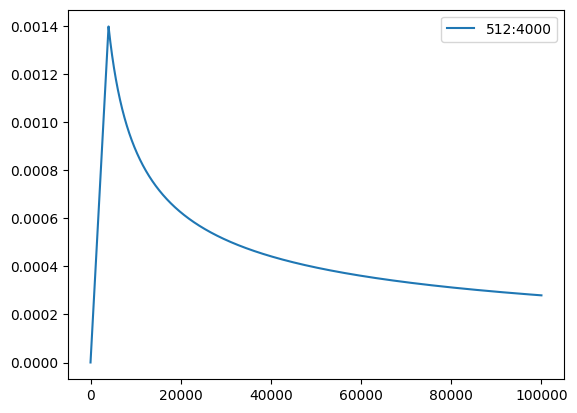

In [37]:
optimizer = NoamOpt(
    model_size=arch_args.encoder_embed_dim, 
    factor=config.lr_factor, 
    warmup=config.lr_warmup, 
    optimizer=torch.optim.AdamW(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.0001))
plt.plot(np.arange(1, 100000), [optimizer.rate(i) for i in range(1, 100000)])
plt.legend([f"{optimizer.model_size}:{optimizer.warmup}"])

# Training Procedure

## Training

In [38]:
from fairseq.data import iterators
from torch.cuda.amp import GradScaler, autocast

def train_one_epoch(epoch_itr, model, task, criterion, optimizer, accum_steps=1):
    itr = epoch_itr.next_epoch_itr(shuffle=True)
    itr = iterators.GroupedIterator(itr, accum_steps) # gradient accumulation: update every accum_steps samples
    
    stats = {"loss": []}
    scaler = GradScaler() # automatic mixed precision (amp) 
    
    model.train()
    progress = tqdm.tqdm(itr, desc=f"train epoch {epoch_itr.epoch}", leave=False)
    for samples in progress:
        model.zero_grad()
        accum_loss = 0
        sample_size = 0
        # gradient accumulation: update every accum_steps samples
        for i, sample in enumerate(samples):
            if i == 1:
                # emptying the CUDA cache after the first step can reduce the chance of OOM
                torch.cuda.empty_cache()

            sample = utils.move_to_cuda(sample, device=device)
            target = sample["target"]
            sample_size_i = sample["ntokens"]
            sample_size += sample_size_i
            
            # mixed precision training
            with autocast():
                net_output = model.forward(**sample["net_input"])
                lprobs = F.log_softmax(net_output[0], -1)            
                loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1))
                
                # logging
                accum_loss += loss.item()
                # back-prop
                scaler.scale(loss).backward()                
        
        scaler.unscale_(optimizer)
        optimizer.multiply_grads(1 / (sample_size or 1.0)) # (sample_size or 1.0) handles the case of a zero gradient
        gnorm = nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm) # grad norm clipping prevents gradient exploding
        
        scaler.step(optimizer)
        scaler.update()
        
        # logging
        loss_print = accum_loss/sample_size
        stats["loss"].append(loss_print)
        progress.set_postfix(loss=loss_print)
        if config.use_wandb:
            wandb.log({
                "train/loss": loss_print,
                "train/grad_norm": gnorm.item(),
                "train/lr": optimizer.rate(),
                "train/sample_size": sample_size,
            })
        
    loss_print = np.mean(stats["loss"])
    logger.info(f"training loss: {loss_print:.4f}")
    return stats

## Validation & Inference
To prevent overfitting, validation is required every epoch to validate the performance on unseen data.
- the procedure is essensially same as training, with the addition of inference step
- after validation we can save the model weights

Validation loss alone cannot describe the actual performance of the model
- Directly produce translation hypotheses based on current model, then calculate BLEU with the reference translation
- We can also manually examine the hypotheses' quality
- We use fairseq's sequence generator for beam search to generate translation hypotheses

In [39]:
# fairseq's beam search generator
# given model and input seqeunce, produce translation hypotheses by beam search
sequence_generator = task.build_generator([model], config)

def decode(toks, dictionary):
    # convert from Tensor to human readable sentence
    s = dictionary.string(
        toks.int().cpu(),
        config.post_process,
    )
    return s if s else "<unk>"

def inference_step(sample, model):
    gen_out = sequence_generator.generate([model], sample)
    srcs = []
    hyps = []
    refs = []
    for i in range(len(gen_out)):
        # for each sample, collect the input, hypothesis and reference, later be used to calculate BLEU
        srcs.append(decode(
            utils.strip_pad(sample["net_input"]["src_tokens"][i], task.source_dictionary.pad()), 
            task.source_dictionary,
        ))
        hyps.append(decode(
            gen_out[i][0]["tokens"], # 0 indicates using the top hypothesis in beam
            task.target_dictionary,
        ))
        refs.append(decode(
            utils.strip_pad(sample["target"][i], task.target_dictionary.pad()), 
            task.target_dictionary,
        ))
    return srcs, hyps, refs

In [40]:
import shutil
import sacrebleu

def validate(model, task, criterion, log_to_wandb=True):
    logger.info('begin validation')
    itr = load_data_iterator(task, "valid", 1, config.max_tokens, config.num_workers).next_epoch_itr(shuffle=False)
    
    stats = {"loss":[], "bleu": 0, "srcs":[], "hyps":[], "refs":[]}
    srcs = []
    hyps = []
    refs = []
    
    model.eval()
    progress = tqdm.tqdm(itr, desc=f"validation", leave=False)
    with torch.no_grad():
        for i, sample in enumerate(progress):
            # validation loss
            sample = utils.move_to_cuda(sample, device=device)
            net_output = model.forward(**sample["net_input"])

            lprobs = F.log_softmax(net_output[0], -1)
            target = sample["target"]
            sample_size = sample["ntokens"]
            loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1)) / sample_size
            progress.set_postfix(valid_loss=loss.item())
            stats["loss"].append(loss)
            
            # do inference
            s, h, r = inference_step(sample, model)
            srcs.extend(s)
            hyps.extend(h)
            refs.extend(r)
            
    tok = 'zh' if task.cfg.target_lang == 'zh' else '13a'
    stats["loss"] = torch.stack(stats["loss"]).mean().item()
    stats["bleu"] = sacrebleu.corpus_bleu(hyps, [refs], tokenize=tok) # 計算BLEU score
    stats["srcs"] = srcs
    stats["hyps"] = hyps
    stats["refs"] = refs
    
    if config.use_wandb and log_to_wandb:
        wandb.log({
            "valid/loss": stats["loss"],
            "valid/bleu": stats["bleu"].score,
        }, commit=False)
    
    showid = np.random.randint(len(hyps))
    logger.info("example source: " + srcs[showid])
    logger.info("example hypothesis: " + hyps[showid])
    logger.info("example reference: " + refs[showid])
    
    # show bleu results
    logger.info(f"validation loss:\t{stats['loss']:.4f}")
    logger.info(stats["bleu"].format())
    return stats

# Save and Load Model Weights


In [41]:
def validate_and_save(model, task, criterion, optimizer, epoch, save=True):   
    stats = validate(model, task, criterion)
    bleu = stats['bleu']
    loss = stats['loss']
    if save:
        # save epoch checkpoints
        savedir = Path(config.savedir).absolute()
        savedir.mkdir(parents=True, exist_ok=True)
        
        check = {
            "model": model.state_dict(),
            "stats": {"bleu": bleu.score, "loss": loss},
            "optim": {"step": optimizer._step}
        }
        torch.save(check, savedir/f"checkpoint{epoch}.pt")
        shutil.copy(savedir/f"checkpoint{epoch}.pt", savedir/f"checkpoint_last.pt")
        logger.info(f"saved epoch checkpoint: {savedir}/checkpoint{epoch}.pt")
    
        # save epoch samples
        with open(savedir/f"samples{epoch}.{config.source_lang}-{config.target_lang}.txt", "w") as f:
            for s, h in zip(stats["srcs"], stats["hyps"]):
                f.write(f"{s}\t{h}\n")

        # get best valid bleu    
        if getattr(validate_and_save, "best_bleu", 0) < bleu.score:
            validate_and_save.best_bleu = bleu.score
            torch.save(check, savedir/f"checkpoint_best.pt")
            
        del_file = savedir / f"checkpoint{epoch - config.keep_last_epochs}.pt"
        if del_file.exists():
            del_file.unlink()
    
    return stats

def try_load_checkpoint(model, optimizer=None, name=None):
    name = name if name else "checkpoint_last.pt"
    checkpath = Path(config.savedir)/name
    if checkpath.exists():
        check = torch.load(checkpath)
        model.load_state_dict(check["model"])
        stats = check["stats"]
        step = "unknown"
        if optimizer != None:
            optimizer._step = step = check["optim"]["step"]
        logger.info(f"loaded checkpoint {checkpath}: step={step} loss={stats['loss']} bleu={stats['bleu']}")
    else:
        logger.info(f"no checkpoints found at {checkpath}!")

# Main
## Training loop

In [42]:
model = model.to(device=device)
criterion = criterion.to(device=device)

In [43]:
logger.info("task: {}".format(task.__class__.__name__))
logger.info("encoder: {}".format(model.encoder.__class__.__name__))
logger.info("decoder: {}".format(model.decoder.__class__.__name__))
logger.info("criterion: {}".format(criterion.__class__.__name__))
logger.info("optimizer: {}".format(optimizer.__class__.__name__))
logger.info(
    "num. model params: {:,} (num. trained: {:,})".format(
        sum(p.numel() for p in model.parameters()),
        sum(p.numel() for p in model.parameters() if p.requires_grad),
    )
)
logger.info(f"max tokens per batch = {config.max_tokens}, accumulate steps = {config.accum_steps}")

2024-10-21 08:48:54 | INFO | hw5.seq2seq | task: TranslationTask
2024-10-21 08:48:54 | INFO | hw5.seq2seq | encoder: TransformerEncoder
2024-10-21 08:48:54 | INFO | hw5.seq2seq | decoder: TransformerDecoder
2024-10-21 08:48:54 | INFO | hw5.seq2seq | criterion: LabelSmoothedCrossEntropyCriterion
2024-10-21 08:48:54 | INFO | hw5.seq2seq | optimizer: NoamOpt
2024-10-21 08:48:54 | INFO | hw5.seq2seq | num. model params: 52,316,160 (num. trained: 52,316,160)
2024-10-21 08:48:54 | INFO | hw5.seq2seq | max tokens per batch = 8192, accumulate steps = 2


In [45]:
epoch_itr = load_data_iterator(task, "train", config.start_epoch, config.max_tokens, config.num_workers)
try_load_checkpoint(model, optimizer, name=config.resume)
while epoch_itr.next_epoch_idx <= config.max_epoch:
    # train for one epoch
    train_one_epoch(epoch_itr, model, task, criterion, optimizer, config.accum_steps)
    stats = validate_and_save(model, task, criterion, optimizer, epoch=epoch_itr.epoch)
    logger.info("end of epoch {}".format(epoch_itr.epoch))    
    epoch_itr = load_data_iterator(task, "train", epoch_itr.next_epoch_idx, config.max_tokens, config.num_workers)

2024-10-21 08:51:02 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-10-21 08:51:02 | INFO | hw5.seq2seq | no checkpoints found at checkpoints\transformer-ted2020_with_mono\checkpoint_last.pt!
2024-10-21 08:51:09 | INFO | fairseq.data.iterators | grouped total_num_itrs = 1865
train epoch 1:   0%|          | 0/1865 [00:00<?, ?it/s]c:\Users\admin\.conda\envs\AI\Lib\site-packages\torch\nn\functional.py:5504: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)
c:\Users\admin\.conda\envs\AI\Lib\site-packages\torch\nn\functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
2024-10-21 09:03:48 | INFO | hw5.seq2seq | training loss: 5.1443             
2024-10-21 09:03:48 | INFO | hw5.seq2seq | begin va

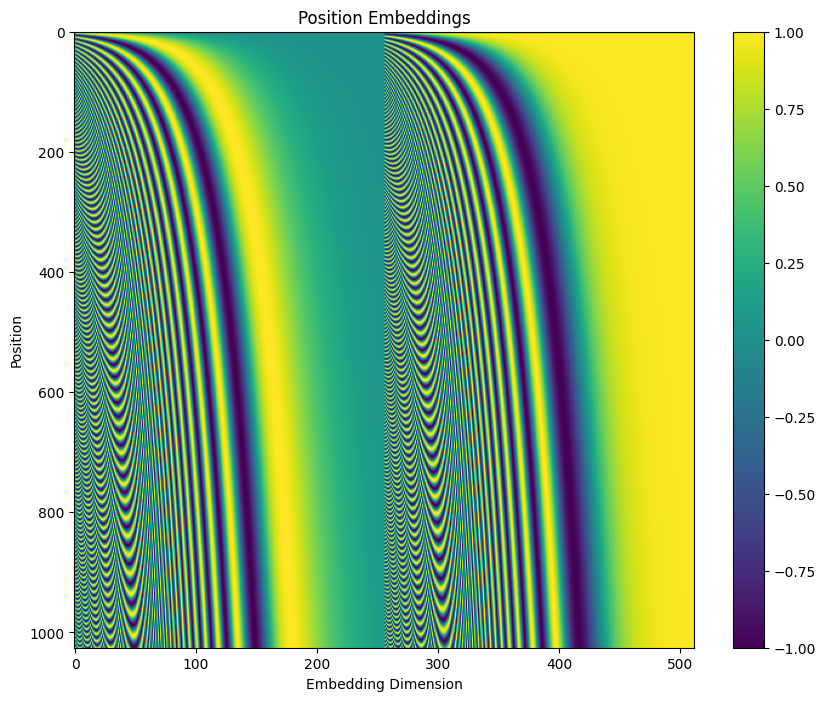

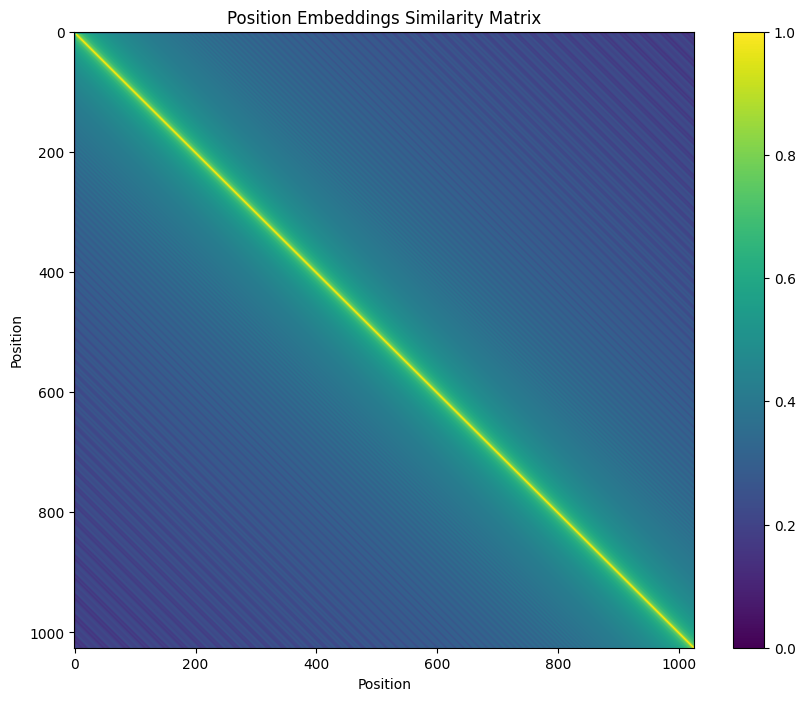

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

pos_emb = model.decoder.embed_positions.weights.cpu().detach()

plt.figure(figsize=(10, 8))
plt.imshow(pos_emb, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Position Embeddings')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.show()

similarity_matrix = cosine_similarity(pos_emb)

# 可视化相似度矩阵
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title('Position Embeddings Similarity Matrix')
plt.xlabel('Position')
plt.ylabel('Position')
plt.show()


# Submission

In [50]:
# averaging a few checkpoints can have a similar effect to ensemble
checkdir=config.savedir
!python ./fairseq/scripts/average_checkpoints.py \
--inputs {checkdir} \
--num-epoch-checkpoints 5 \
--output {checkdir}/avg_last_5_checkpoint.pt

Namespace(inputs=['./checkpoints/transformer-ted2020_with_mono'], output='./checkpoints/transformer-ted2020_with_mono/avg_last_5_checkpoint.pt', num_epoch_checkpoints=5, num_update_checkpoints=None, checkpoint_upper_bound=None)
averaging checkpoints:  ['./checkpoints/transformer-ted2020_with_mono\\checkpoint30.pt', './checkpoints/transformer-ted2020_with_mono\\checkpoint29.pt', './checkpoints/transformer-ted2020_with_mono\\checkpoint28.pt', './checkpoints/transformer-ted2020_with_mono\\checkpoint27.pt', './checkpoints/transformer-ted2020_with_mono\\checkpoint26.pt']
Finished writing averaged checkpoint to ./checkpoints/transformer-ted2020_with_mono/avg_last_5_checkpoint.pt


2024-10-21 15:29:20 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX


## Confirm model weights used to generate submission

In [51]:
# checkpoint_last.pt : latest epoch
# checkpoint_best.pt : highest validation bleu
# avg_last_5_checkpoint.pt:　the average of last 5 epochs
try_load_checkpoint(model, name="checkpoint_best.pt")
validate(model, task, criterion, log_to_wandb=False)

2024-10-21 15:29:27 | INFO | hw5.seq2seq | loaded checkpoint checkpoints\transformer-ted2020_with_mono\avg_last_5_checkpoint.pt: step=unknown loss=2.9864537715911865 bleu=28.938376299854845
2024-10-21 15:29:27 | INFO | hw5.seq2seq | begin validation
2024-10-21 15:29:27 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
validation:   0%|          | 0/22 [00:00<?, ?it/s]c:\Users\admin\.conda\envs\AI\Lib\site-packages\torch\nn\functional.py:5137: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
2024-10-21 15:29:55 | INFO | hw5.seq2seq | example source: now , why are algorithms even important ?
2024-10-21 15:29:55 | INFO | hw5.seq2seq | example hypothesis: 那麼 , 為什麼演算法還重要呢 ?
2024-10-21 15:29:55 | INFO | hw5.seq2seq | example reference: 為什麼演算法如此重要 ?
2024-10-21 15:29:55 | INFO | hw5.seq2seq | validation loss:	2.9542
2024-10-21 15:29:55 | INFO | hw5.seq2seq | BLEU = 29.14 60.6/36.4/23.2/15.7 (BP = 0

{'loss': 2.9542250633239746,
 'bleu': BLEU = 29.14 60.6/36.4/23.2/15.7 (BP = 0.974 ratio = 0.974 hyp_len = 109346 ref_len = 112254),
 'srcs': ['so they hatched a plan .',
  "it's an incredible story .",
  "well , here's a really big one .",
  'here are some of the things that we do .',
  "and that's just the start of it .",
  'which brought us to this .',
  "and here's a prime example .",
  "actually , you didn't even live together .",
  "now , here's the really interesting part .",
  "it's on this side of the brain .",
  "and then there's the wanting system .",
  'and that was on july 27th .',
  "so , it's the year 2000 .",
  'now , how many people know what this is ?',
  "let's take a look at this house .",
  '4 am in the morning .',
  'but we know how to fix this .',
  'these oceans are very much alive .',
  'it has a chamber hall .',
  "and it's not going to be easy .",
  "but he wasn't dismayed .",
  "that's the place vendôme .",
  'it impacts sentencing .',
  'i\'m going with you

## Generate Prediction

In [47]:
def generate_prediction(model, task, split="test", outfile="./prediction.txt"):    
    task.load_dataset(split=split, epoch=1)
    itr = load_data_iterator(task, split, 1, config.max_tokens, config.num_workers).next_epoch_itr(shuffle=False)
    
    idxs = []
    hyps = []

    model.eval()
    progress = tqdm.tqdm(itr, desc=f"prediction")
    with torch.no_grad():
        for i, sample in enumerate(progress):
            # validation loss
            sample = utils.move_to_cuda(sample, device=device)

            # do inference
            s, h, r = inference_step(sample, model)
            
            hyps.extend(h)
            idxs.extend(list(sample['id']))
            
    # sort based on the order before preprocess
    hyps = [x for _,x in sorted(zip(idxs,hyps))]
    
    with open(outfile, "w") as f:
        for h in hyps:
            f.write(h+"\n")

In [48]:
generate_prediction(model, task)

2024-10-20 09:16:10 | INFO | fairseq.data.data_utils | loaded 4,000 examples from: ./DATA/data-bin/ted2020\test.en-zh.zh
2024-10-20 09:16:10 | INFO | fairseq.data.data_utils | loaded 4,000 examples from: ./DATA/data-bin/ted2020\test.en-zh.en
2024-10-20 09:16:10 | INFO | fairseq.tasks.translation | ./DATA/data-bin/ted2020 test zh-en 4000 examples
2024-10-20 09:16:10 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-10-20 09:16:10 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-10-20 09:16:10 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-10-20 09:16:10 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1
prediction:   0%|          | 0/18 [00:00<?, ?it/s]

1


prediction:   6%|▌         | 1/18 [00:00<00:14,  1.19it/s]

1


prediction:  11%|█         | 2/18 [00:01<00:08,  1.78it/s]

...

1


prediction:  83%|████████▎ | 15/18 [00:04<00:00,  5.15it/s]

1
1


prediction: 100%|██████████| 18/18 [00:04<00:00,  3.93it/s]


1
1
111


In [49]:
# raise

# Back-translation

## Train a backward translation model

1. Switch the source_lang and target_lang in **config** 
2. Change the savedir in **config** (eg. "./checkpoints/transformer-back")
3. Train model

## Generate synthetic data with backward model 

### Download monolingual data

In [94]:
mono_dataset_name = 'mono'

In [95]:
import os
import urllib.request
import zipfile
import tarfile
import gzip
from pathlib import Path

mono_prefix = Path(data_dir).absolute() / mono_dataset_name
mono_prefix.mkdir(parents=True, exist_ok=True)

urls = (
    "https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ted_zh_corpus.deduped.gz"
)
file_names = (
    'ted_zh_corpus.deduped.gz',
)

# for u, f in zip(urls, file_names):
#     path = mono_prefix/f
#     if not path.exists():
#         else:
#             !wget {u} -O {path}
#     else:
#         print(f'{f} is exist, skip downloading')
#     if path.suffix == ".tgz":
#         !tar -xvf {path} -C {prefix}
#     elif path.suffix == ".zip":
#         !unzip -o {path} -d {prefix}
#     elif path.suffix == ".gz":
#         !gzip -fkd {path}

print(urls)
for u, f in zip(urls, file_names):
    u = "https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ted_zh_corpus.deduped.gz"
    path = mono_prefix / f
    print(file_names)
    if not path.exists():
        # 下载文件
        print(f'Downloading {f} from {u}')
        urllib.request.urlretrieve(u, path)
    else:
        print(f'{f} already exists, skipping download')

    # 解压文件
    if path.suffix == ".tgz":
        print(f'Extracting {f}')
        with tarfile.open(path, "r:gz") as tar:
            tar.extractall(prefix)
    elif path.suffix == ".zip":
        print(f'Extracting {f}')
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(prefix)
    elif path.suffix == ".gz":
        print(f'Extracting {f}')
        with gzip.open(path, 'rb') as f_in:
            with open(path.with_suffix(''), 'wb') as f_out:
                f_out.write(f_in.read())


https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ted_zh_corpus.deduped.gz
('ted_zh_corpus.deduped.gz',)
ted_zh_corpus.deduped.gz already exists, skipping download
Extracting ted_zh_corpus.deduped.gz


### TODO: clean corpus

1. remove sentences that are too long or too short
2. unify punctuation

hint: you can use clean_s() defined above to do this

In [52]:
print(mono_prefix)
mono_data = mono_prefix / "ted_zh_corpus.deduped"
print(mono_data)
def clean_mono_corpus(mono_data, lang ,min_len=1, max_len=1000):
    if Path(f'{mono_data}.clean.zh').exists():
        print(f'{mono_data}.clean.zh exists. skipping clean.')
        return
    else:
        with open(mono_data, "r") as input:
            with open(f'{mono_data}.clean.zh', "w") as out:
                for line in input:
                    line = line.strip()
                    line = clean_s(line, lang)
                    line_len = len_s(line, lang)
                    if min_len > 0: # remove short sentence
                        if line_len < min_len :
                            continue
                    if max_len > 0: # remove long sentence
                        if line_len > max_len :
                            continue
    
                    print(line, file=out)

clean_mono_corpus(mono_data, "zh")

# clean_corpus(mono_data,tgt_lang,src_lang)
# clean_corpus(test_prefix, src_lang, tgt_lang, ratio=-1, min_len=-1, max_len=-1)

e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\mono
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\mono\ted_zh_corpus.deduped
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\mono\ted_zh_corpus.deduped.clean.zh exists. skipping clean.


In [99]:
# mono对应的英文数据

print(mono_prefix)
mono_data = mono_prefix / "ted_zh_corpus.deduped.en"
print(mono_data)
def clean_mono_corpus(mono_data, lang ,min_len=1, max_len=1000):
    if Path(f'{mono_data}.clean.en').exists():
        print(f'{mono_data}.clean.en exists. skipping clean.')
        return
    else:
        with open(mono_data, "r") as input:
            with open(f'{mono_data}.clean.en', "w") as out:
                for line in input:
                    line = line.strip()
                    line = clean_s(line, lang)
                    line_len = len_s(line, lang)
                    if min_len > 0: # remove short sentence
                        if line_len < min_len :
                            continue
                    if max_len > 0: # remove long sentence
                        if line_len > max_len :
                            continue
    
                    print(line, file=out)

clean_mono_corpus(mono_data, "en")

e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\mono
e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\mono\ted_zh_corpus.deduped.en


In [53]:
# import os

# zh_path = mono_prefix / 'ted_zh_corpus.deduped.clean.zh'
# en_path = mono_prefix / 'ted_zh_corpus.deduped.clean.en'

# if en_path.exists():
#     print(f"{en_path} exists. skipping the generation of psuedo translation.")
# else:
#     with open(zh_path, 'r') as zh_f:
#         with open(en_path, 'w') as en_f:
#             for line in zh_f:
#                 line = line.strip()
#                 if line:
#                     # 用'_.'替换，得到一个伪翻译的字符串
#                     pseudo = '_.'
#                     # 将伪翻译的字符串写入目标文件中，并换行
#                     print(pseudo, file=en_f)
#                 # 如果这一行为空，直接换行
#                 else:
#                     print(file=en_f)

e:\Learn\Lhy_Machine_Learning-main\2022-ML\05-Sequence_to_sequence\DATA\rawdata\mono\ted_zh_corpus.deduped.clean.en exists. skipping the generation of psuedo translation.


### TODO: Subword Units

Use the spm model of the backward model to tokenize the data into subword units

hint: spm model is located at DATA/raw-data/\[dataset\]/spm\[vocab_num\].model

In [102]:
mono_data = mono_prefix / "ted_zh_corpus.deduped"
spm_model = spm.SentencePieceProcessor(model_file=str(prefix/f'spm{vocab_size}.model'))
in_tag = {
    'train': 'clean',
    'valid': 'valid.clean',
    'test': 'test.raw.clean',
}
for lang in [src_lang, tgt_lang]:
    out_path = mono_prefix / f'mono.tok.{lang}'
    if out_path.exists(): 
        print(f"{out_path} exists. skipping spm_encode.")
    else:
        with open(out_path, 'w') as out_f:
            with open(f'{mono_data}.{in_tag["train"]}.{lang}', 'r') as in_f:
                for line in in_f:
                    line = line.strip()
                    tok = spm_model.encode(line, out_type=str)
                    print(' '.join(tok), file=out_f)

### Binarize

use fairseq to binarize data

In [103]:
binpath = Path('./DATA/data-bin', mono_dataset_name)
src_dict_file = './DATA/data-bin/ted2020/dict.en.txt'
tgt_dict_file = src_dict_file
monopref = str(mono_prefix/"mono.tok") # whatever filepath you get after applying subword tokenization
!python -m fairseq_cli.preprocess\
    --source-lang {tgt_lang}\
    --target-lang {src_lang}\
    --trainpref {monopref}\
    --destdir {binpath}\
    --srcdict {src_dict_file}\
    --tgtdict {tgt_dict_file}\
    --workers 2

2024-10-20 13:42:17 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2024-10-20 13:42:17 | INFO | fairseq_cli.preprocess | Namespace(no_progress_bar=False, log_interval=100, log_format=None, log_file=None, aim_repo=None, aim_run_hash=None, tensorboard_logdir=None, wandb_project=None, azureml_logging=False, seed=1, cpu=False, tpu=False, bf16=False, memory_efficient_bf16=False, fp16=False, memory_efficient_fp16=False, fp16_no_flatten_grads=False, fp16_init_scale=128, fp16_scale_window=None, fp16_scale_tolerance=0.0, on_cpu_convert_precision=False, min_loss_scale=0.0001, threshold_loss_scale=None, amp=False, amp_batch_retries=2, amp_init_scale=128, amp_scale_window=None, user_dir=None, empty_cache_freq=0, all_gather_list_size=16384, model_parallel_size=1, quantization_config_path=None, profile=False, reset_logging=False, suppress_crashes=False, use_plasma_view=False, plasma_path='/tmp/plasma', criterion='cross_entropy', tokenizer=None, bpe=None

### TODO: Generate synthetic data with backward model

Add binarized monolingual data to the original data directory, and name it with "split_name"

ex. ./DATA/data-bin/ted2020/\[split_name\].zh-en.\["en", "zh"\].\["bin", "idx"\]

then you can use 'generate_prediction(model, task, split="split_name")' to generate translation prediction

In [104]:
# Add binarized monolingual data to the original data directory, and name it with "split_name"
# ex. ./DATA/data-bin/ted2020/\[split_name\].zh-en.\["en", "zh"\].\["bin", "idx"\]
# !cp ./DATA/data-bin/mono/train.zh-en.zh.bin ./DATA/data-bin/ted2020/mono.zh-en.zh.bin
# !cp ./DATA/data-bin/mono/train.zh-en.zh.idx ./DATA/data-bin/ted2020/mono.zh-en.zh.idx
# !cp ./DATA/data-bin/mono/train.zh-en.en.bin ./DATA/data-bin/ted2020/mono.zh-en.en.bin
# !cp ./DATA/data-bin/mono/train.zh-en.en.idx ./DATA/data-bin/ted2020/mono.zh-en.en.idx


import shutil

# 定义源文件和目标文件路径
files_to_copy = [
    ("./DATA/data-bin/mono/train.zh-en.zh.bin", "./DATA/data-bin/ted2020/mono.zh-en.zh.bin"),
    ("./DATA/data-bin/mono/train.zh-en.zh.idx", "./DATA/data-bin/ted2020/mono.zh-en.zh.idx"),
    ("./DATA/data-bin/mono/train.zh-en.en.bin", "./DATA/data-bin/ted2020/mono.zh-en.en.bin"),
    ("./DATA/data-bin/mono/train.zh-en.en.idx", "./DATA/data-bin/ted2020/mono.zh-en.en.idx")
]

# 复制文件
for src, dst in files_to_copy:
    shutil.copy(src, dst)
    print(f"Copied {src} to {dst}")

Copied ./DATA/data-bin/mono/train.zh-en.zh.bin to ./DATA/data-bin/ted2020/mono.zh-en.zh.bin
Copied ./DATA/data-bin/mono/train.zh-en.zh.idx to ./DATA/data-bin/ted2020/mono.zh-en.zh.idx
Copied ./DATA/data-bin/mono/train.zh-en.en.bin to ./DATA/data-bin/ted2020/mono.zh-en.en.bin
Copied ./DATA/data-bin/mono/train.zh-en.en.idx to ./DATA/data-bin/ted2020/mono.zh-en.en.idx


In [57]:
# hint: do prediction on split='mono' to create prediction_file
generate_prediction(model, task, split='mono', outfile='./prediction.txt')

2024-10-20 09:18:12 | INFO | fairseq.data.data_utils | loaded 781,713 examples from: ./DATA/data-bin/ted2020\mono.zh-en.zh
2024-10-20 09:18:12 | INFO | fairseq.data.data_utils | loaded 781,713 examples from: ./DATA/data-bin/ted2020\mono.zh-en.en
2024-10-20 09:18:12 | INFO | fairseq.tasks.translation | ./DATA/data-bin/ted2020 mono zh-en 781713 examples
2024-10-20 09:18:12 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-10-20 09:18:12 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-10-20 09:18:12 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = False
2024-10-20 09:18:12 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 1
prediction:   0%|          | 0/1722 [00:00<?, ?it/s]

1


prediction:   0%|          | 1/1722 [00:02<1:15:13,  2.62s/it]

1


prediction:   0%|          | 2/1722 [00:04<57:48,  2.02s/it]  

...

1


prediction: 100%|█████████▉| 1721/1722 [36:00<00:03,  3.82s/it]

1


prediction: 100%|██████████| 1722/1722 [36:07<00:00,  1.26s/it]


111


### TODO: Create new dataset

1. Combine the prediction data with monolingual data
2. Use the original spm model to tokenize data into Subword Units
3. Binarize data with fairseq

In [105]:
# Combine prediction_file (.en) and mono.zh (.zh) into a new dataset.
# 
# hint: tokenize prediction_file with the spm model
# spm_model.encode(line, out_type=str)
# output: ./DATA/rawdata/mono/mono.tok.en & mono.tok.zh
#
# hint: use fairseq to binarize these two files again
binpath = Path('./DATA/data-bin/synthetic')
src_dict_file = './DATA/data-bin/ted2020/dict.en.txt'
tgt_dict_file = src_dict_file
monopref = "./DATA/rawdata/mono/mono.tok" # or whatever path after applying subword tokenization, w/o the suffix (.zh/.en)
if binpath.exists():
    print(binpath, "exists, will not overwrite!")
else:
    !python -m fairseq_cli.preprocess\
        --source-lang zh\
        --target-lang en\
        --trainpref {monopref}\
        --destdir {binpath}\
        --srcdict {src_dict_file}\
        --tgtdict {tgt_dict_file}\
        --workers 2


2024-10-20 13:48:42 | INFO | fairseq.tasks.text_to_speech | Please install tensorboardX: pip install tensorboardX
2024-10-20 13:48:43 | INFO | fairseq_cli.preprocess | Namespace(no_progress_bar=False, log_interval=100, log_format=None, log_file=None, aim_repo=None, aim_run_hash=None, tensorboard_logdir=None, wandb_project=None, azureml_logging=False, seed=1, cpu=False, tpu=False, bf16=False, memory_efficient_bf16=False, fp16=False, memory_efficient_fp16=False, fp16_no_flatten_grads=False, fp16_init_scale=128, fp16_scale_window=None, fp16_scale_tolerance=0.0, on_cpu_convert_precision=False, min_loss_scale=0.0001, threshold_loss_scale=None, amp=False, amp_batch_retries=2, amp_init_scale=128, amp_scale_window=None, user_dir=None, empty_cache_freq=0, all_gather_list_size=16384, model_parallel_size=1, quantization_config_path=None, profile=False, reset_logging=False, suppress_crashes=False, use_plasma_view=False, plasma_path='/tmp/plasma', criterion='cross_entropy', tokenizer=None, bpe=None

In [1]:
# create a new dataset from all the files prepared above
# !cp -r ./DATA/data-bin/ted2020/ ./DATA/data-bin/ted2020_with_mono/

# !cp ./DATA/data-bin/synthetic/train.zh-en.zh.bin ./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.bin
# !cp ./DATA/data-bin/synthetic/train.zh-en.zh.idx ./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.idx
# !cp ./DATA/data-bin/synthetic/train.zh-en.en.bin ./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.bin
# !cp ./DATA/data-bin/synthetic/train.zh-en.en.idx ./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.idx

import shutil
import os

# 复制整个目录
src_dir = './DATA/data-bin/ted2020/'
dst_dir = './DATA/data-bin/ted2020_with_mono/'

# 确保目标目录存在
if not os.path.exists(dst_dir):
    shutil.copytree(src_dir, dst_dir)
else:
    print(f"Directory {dst_dir} already exists, skipping copy.")

# 定义源文件和目标文件路径
files_to_copy = [
    ("./DATA/data-bin/synthetic/train.zh-en.zh.bin", "./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.bin"),
    ("./DATA/data-bin/synthetic/train.zh-en.zh.idx", "./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.idx"),
    ("./DATA/data-bin/synthetic/train.zh-en.en.bin", "./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.bin"),
    ("./DATA/data-bin/synthetic/train.zh-en.en.idx", "./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.idx")
]

with open('./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.bin', 'w') as f:
    pass

# 复制文件
for src, dst in files_to_copy:
    shutil.copy(src, dst)
    print(f"Copied {src} to {dst}")

Directory ./DATA/data-bin/ted2020_with_mono/ already exists, skipping copy.
Copied ./DATA/data-bin/synthetic/train.zh-en.zh.bin to ./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.bin
Copied ./DATA/data-bin/synthetic/train.zh-en.zh.idx to ./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.idx
Copied ./DATA/data-bin/synthetic/train.zh-en.en.bin to ./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.bin
Copied ./DATA/data-bin/synthetic/train.zh-en.en.idx to ./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.idx


Created new dataset "ted2020_with_mono"

1. Change the datadir in **config** ("./DATA/data-bin/ted2020_with_mono")
2. Switch back the source_lang and target_lang in **config** ("en", "zh")
2. Change the savedir in **config** (eg. "./checkpoints/transformer-bt")
3. Train model

1. <a name=ott2019fairseq></a>Ott, M., Edunov, S., Baevski, A., Fan, A., Gross, S., Ng, N., ... & Auli, M. (2019, June). fairseq: A Fast, Extensible Toolkit for Sequence Modeling. In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics (Demonstrations) (pp. 48-53).
2. <a name=vaswani2017></a>Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017, December). Attention is all you need. In Proceedings of the 31st International Conference on Neural Information Processing Systems (pp. 6000-6010).
3. <a name=reimers-2020-multilingual-sentence-bert></a>Reimers, N., & Gurevych, I. (2020, November). Making Monolingual Sentence Embeddings Multilingual Using Knowledge Distillation. In Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing (EMNLP) (pp. 4512-4525).
4. <a name=tiedemann2012parallel></a>Tiedemann, J. (2012, May). Parallel Data, Tools and Interfaces in OPUS. In Lrec (Vol. 2012, pp. 2214-2218).
5. <a name=kudo-richardson-2018-sentencepiece></a>Kudo, T., & Richardson, J. (2018, November). SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing. In Proceedings of the 2018 Conference on Empirical Methods in Natural Language Processing: System Demonstrations (pp. 66-71).
6. <a name=sennrich-etal-2016-improving></a>Sennrich, R., Haddow, B., & Birch, A. (2016, August). Improving Neural Machine Translation Models with Monolingual Data. In Proceedings of the 54th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers) (pp. 86-96).
7. <a name=edunov-etal-2018-understanding></a>Edunov, S., Ott, M., Auli, M., & Grangier, D. (2018). Understanding Back-Translation at Scale. In Proceedings of the 2018 Conference on Empirical Methods in Natural Language Processing (pp. 489-500).
8. https://github.com/ajinkyakulkarni14/TED-Multilingual-Parallel-Corpus
9. https://ithelp.ithome.com.tw/articles/10233122
10. https://nlp.seas.harvard.edu/2018/04/03/attention.html
11. https://colab.research.google.com/github/ga642381/ML2021-Spring/blob/main/HW05/HW05.ipynb